In [5]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import os
data_dir = os.getcwd() + '/data/'

In [6]:
data_100C = np.loadtxt(data_dir + 'a-Si PECVD 20190514/100C_20190514.CSV', delimiter=';')
data_250C = np.loadtxt(data_dir + 'a-Si PECVD 20190514/250C_20190514.CSV', delimiter=';')
data_350C = np.loadtxt(data_dir + 'a-Si PECVD 20190514/350C_20190514.CSV', delimiter=';')
data_background = np.loadtxt(data_dir + 'a-Si PECVD 20190514/background_20190514.CSV', delimiter=';')
data_background_unox = np.loadtxt(data_dir + 'a-Si_PECVD_20190430/background_blank_wafer_crystalline_Si_20190430.CSV', delimiter=';')
data_empty_holder = np.loadtxt(data_dir + 'Empty 20190604/background_empty_20190604.CSV', delimiter=';')

In [7]:
# -*- coding: utf-8 -*-
"""
Examples of plots and calculations using the tmm package.
"""

from __future__ import division, print_function, absolute_import

from tmm.tmm_core import coh_tmm
from tmm.tmm_core import inc_tmm

from numpy import pi, linspace, inf, array
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from scipy.ndimage.filters import gaussian_filter1d as gauss

In [8]:
wavenumbers_cm = np.array([4000, 400]) # cm-1
wavelengths_cm = 1/wavenumbers_cm
wavelengths_nm = 1e7 * wavelengths_cm

## Fit silicon wafer optical constants

In [169]:
def sub_k(x,a,b):
    k = 10**a * x**b
    return k

def transmission_sub_disp(x, a, b):   
    c_list = ['i','i','i']
    d_list = [inf, 515*1e3, inf] #in nm
    lambda_list = x
    T_list = []
    for lambda_vac in lambda_list:
        n_list = [1, np.complex(3.45,sub_k(lambda_vac, a, b)), 1]
        T_list.append(inc_tmm('s', n_list, d_list, c_list, 0, lambda_vac)['T'])
    return T_list

def transmission_sub(x, k):   
    c_list = ['i','i','i']
    d_list = [inf, 515*1e3, inf] #in nm
    lambda_list = x
    T_list = []
    for lambda_vac in lambda_list:
        n_list = [1, np.complex(3.45,k), 1]
        T_list.append(inc_tmm('s', n_list, d_list, c_list, 0, lambda_vac)['T'])
    return T_list

p0 = [0.002]
p0_disp = [float(-4), float(1)]
bounds_disp = ([-np.inf, 0.5],[np.inf, 10])
x_wavenumbers_cm = data_background_unox[:,0]
x_wavelengths_nm = 1e7 * 1/x_wavenumbers_cm
y = data_background_unox[:,1]/data_empty_holder[:,1]
x_fitting = x_wavelengths_nm[x_wavenumbers_cm > 1750]
y_fitting = y[x_wavenumbers_cm > 1750]

popt_disp, pcov_disp = curve_fit(transmission_sub_disp, x_fitting, y_fitting, p0=p0_disp, bounds=bounds_disp)
popt, pcov = curve_fit(transmission_sub, x_fitting, y_fitting, p0=p0)

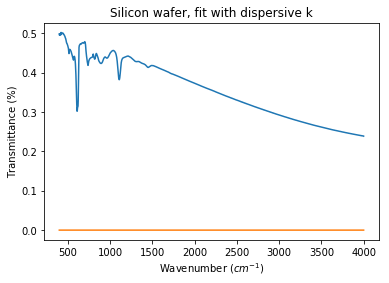

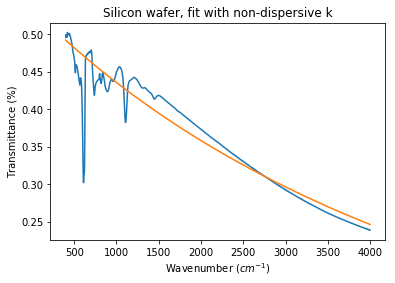

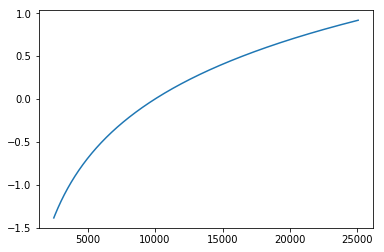

In [170]:
fig, ax = plt.subplots()
ax.plot(data_350C[:,0], data_background_unox[:,1]/data_empty_holder[:,1])
ax.set_title("Silicon wafer, fit with dispersive k")
ax.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax.set_ylabel('Transmittance (%)')
ax.plot(x_wavenumbers_cm, transmission_sub_disp(x_wavelengths_nm, *popt_disp))

fig, ax = plt.subplots()
ax.plot(data_350C[:,0], data_background_unox[:,1]/data_empty_holder[:,1])
ax.set_title("Silicon wafer, fit with non-dispersive k")
ax.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax.set_ylabel('Transmittance (%)')
ax.plot(x_wavenumbers_cm, transmission_sub(x_wavelengths_nm, *popt))

plt.figure()
plt.plot(x_wavelengths_nm, np.log(sub_k(x_wavelengths_nm, *popt_disp)))

In [166]:
sub_k(x_wavelengths_nm, *popt_disp)

array([0.00016577, 0.00016597, 0.00016616, ..., 0.00029254, 0.00029258,
       0.00029261])

In [167]:
popt_disp

array([-2.69582205, -0.24658418])

## Absorbances of a-Si layers

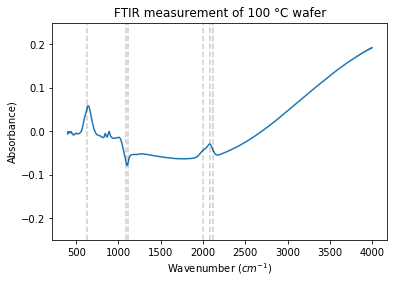

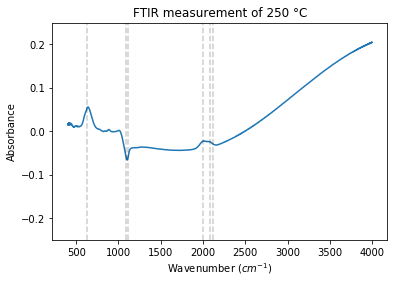

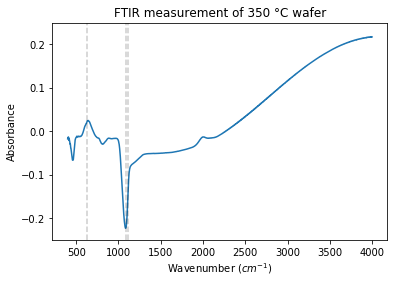

In [29]:
fig, ax = plt.subplots()
ax.plot(data_100C[:,0], 2-np.log10(data_100C[:,1]))
ax.set_title("FTIR measurement of 100 °C wafer")
ax.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax.set_ylabel('Absorbance)')
ax.set_ylim([-0.25, 0.25])
ax.axvline(2003, linestyle='--', color = 'k', alpha = 0.2)
ax.axvline(2080, linestyle='--', color = 'k', alpha = 0.2)
ax.axvline(2120, linestyle='--', color = 'k', alpha = 0.2)
ax.axvline(630, linestyle='--', color = 'k', alpha = 0.2)
ax.axvline(1085, linestyle='--', color = 'k', alpha = 0.2)
ax.axvline(1107, linestyle='--', color = 'k', alpha = 0.2)

fig, ax = plt.subplots()
ax.plot(data_250C[:,0], 2-np.log10(data_250C[:,1]))
ax.set_title("FTIR measurement of 250 °C")
ax.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax.set_ylabel('Absorbance')
ax.set_ylim([-0.25, 0.25])
ax.axvline(2003, linestyle='--', color = 'k', alpha = 0.2)
ax.axvline(2080, linestyle='--', color = 'k', alpha = 0.2)
ax.axvline(2120, linestyle='--', color = 'k', alpha = 0.2)
ax.axvline(630, linestyle='--', color = 'k', alpha = 0.2)
ax.axvline(1085, linestyle='--', color = 'k', alpha = 0.2)
ax.axvline(1107, linestyle='--', color = 'k', alpha = 0.2)

fig, ax = plt.subplots()
ax.plot(data_350C[:,0], 2-np.log10(data_350C[:,1]))
ax.set_title("FTIR measurement of 350 °C wafer")
ax.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax.set_ylabel('Absorbance')
ax.set_ylim([-0.25, 0.25])
ax.axvline(630, linestyle='--', color = 'k', alpha = 0.2)
ax.axvline(1085, linestyle='--', color = 'k', alpha = 0.2)
ax.axvline(1107, linestyle='--', color = 'k', alpha = 0.2)

## Data analysis

R: 0.5061542505893437
C: 3.1790075618034067e-06


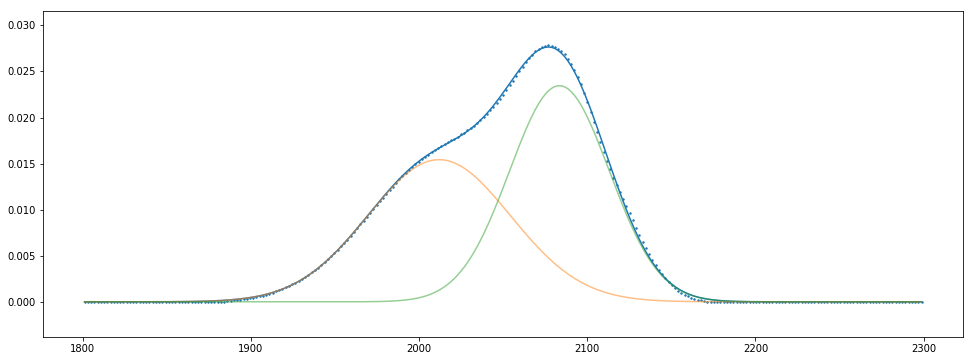

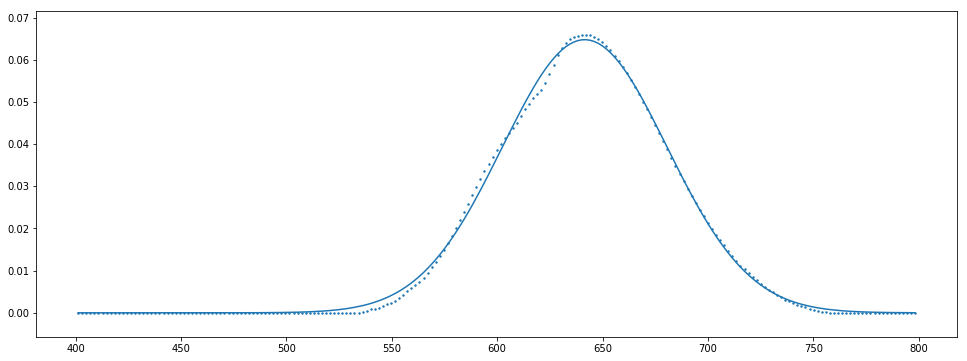

In [3]:
from FTIR_fitting import fit_FTIR
fit_FTIR(data_100C, 253)

R: 0.29673865381299397
C: 0.22041327446832362


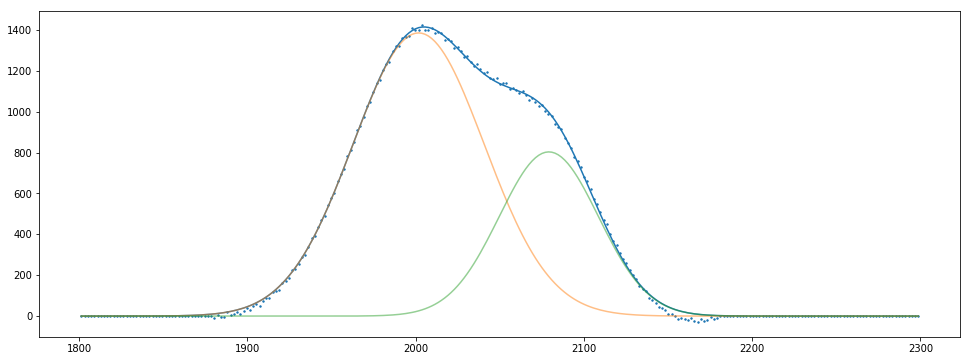

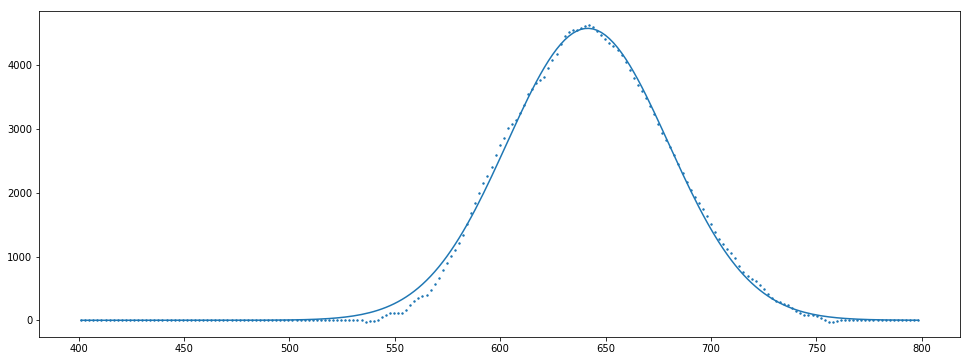

In [4]:
from FTIR_fitting import fit_FTIR
fit_FTIR(data_250C, 237)

R: 0.11550587248730113
C: 0.16625793153217955


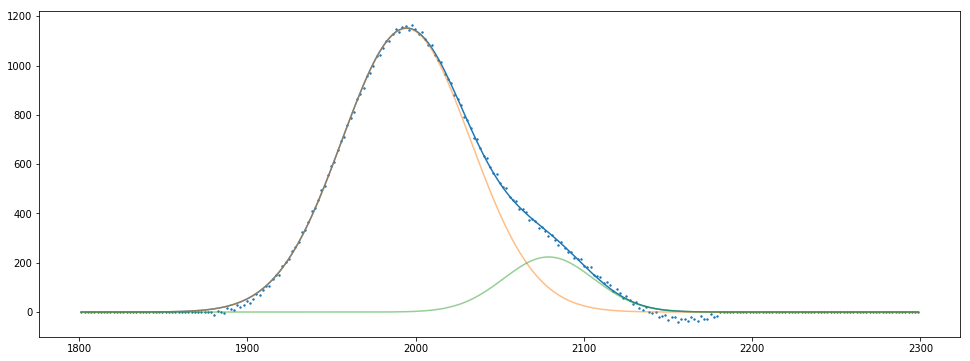

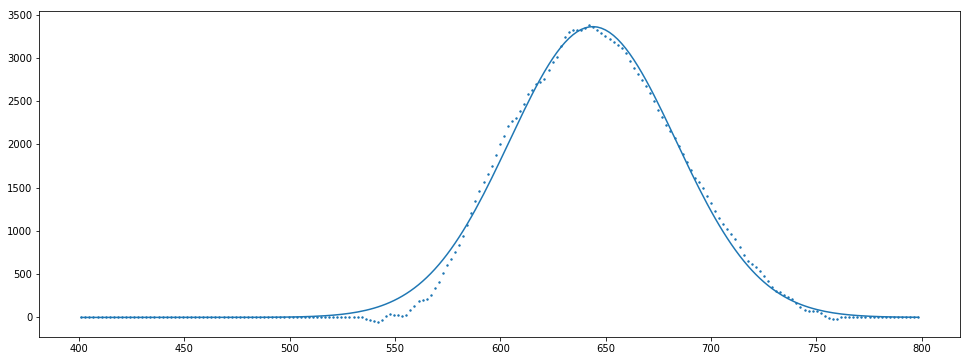

In [5]:
from FTIR_fitting import fit_FTIR
fit_FTIR(data_350C, 261)

In [12]:
len(data_empty_holder[:,1])

1868

In [78]:
10**-4

0.0001

In [79]:
b

NameError: name 'b' is not defined

In [126]:
a,b = -2.7, -0.25

In [127]:
k = 10**a * (x/1000)**b

In [128]:
k

array([0.00158677, 0.00158487, 0.00158297, ..., 0.00089252, 0.00089242,
       0.00089231])

In [83]:
x

array([ 2500.        ,  2512.05141939,  2524.10283878, ...,
       24975.89716122, 24987.94858061, 25000.        ])